### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

### Load the Modeling Datset

In [3]:
df = pd.read_csv("../data/processing/modeling_dataset.csv")
df.head()


,ticker,date,sma_20,bb_width,volume_ratio,volume_sma_20,rsi_14,macd_histogram,true_range,volatility_20,momentum_10,sp500_close,nasdaq_close,vix_close,trend_label
0,STK001,2021-01-04,160.110000,6.363961,1.000000,962644.00,100.000000,0.000000,2.88,0.012463,-0.008557,3891.04,12952.02,20.48,Uptrend
1,STK001,2021-01-05,161.235000,6.363961,1.153842,1137664.50,100.000000,0.143590,5.39,0.012463,-0.008557,3847.20,13116.52,19.89,Sideways
2,STK001,2021-01-06,161.416667,4.672701,1.167277,1241502.00,79.505300,0.188720,1.57,0.012463,-0.008557,3878.24,12818.48,20.02,Sideways
3,STK001,2021-01-07,162.830000,11.933013,1.167320,1314834.75,92.857143,0.543952,6.12,0.018138,-0.008557,3803.95,13290.11,19.59,Downtrend
4,STK001,2021-01-08,163.400000,11.523437,0.694431,1221520.00,79.284963,0.647386,4.08,0.018663,-0.008557,3715.64,13365.73,20.14,Downtrend


In [4]:
df.shape

(15500, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          15500 non-null  object 
 1   date            15500 non-null  object 
 2   sma_20          15500 non-null  float64
 3   bb_width        15500 non-null  float64
 4   volume_ratio    15500 non-null  float64
 5   volume_sma_20   15500 non-null  float64
 6   rsi_14          15500 non-null  float64
 7   macd_histogram  15500 non-null  float64
 8   true_range      15500 non-null  float64
 9   volatility_20   15500 non-null  float64
 10  momentum_10     15500 non-null  float64
 11  sp500_close     15500 non-null  float64
 12  nasdaq_close    15500 non-null  float64
 13  vix_close       15500 non-null  float64
 14  trend_label     15500 non-null  object 
dtypes: float64(12), object(3)
memory usage: 1.8+ MB


In [6]:
# To change date to pandas datetime

df['date'] = pd.to_datetime(df['date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticker          15500 non-null  object        
 1   date            15500 non-null  datetime64[ns]
 2   sma_20          15500 non-null  float64       
 3   bb_width        15500 non-null  float64       
 4   volume_ratio    15500 non-null  float64       
 5   volume_sma_20   15500 non-null  float64       
 6   rsi_14          15500 non-null  float64       
 7   macd_histogram  15500 non-null  float64       
 8   true_range      15500 non-null  float64       
 9   volatility_20   15500 non-null  float64       
 10  momentum_10     15500 non-null  float64       
 11  sp500_close     15500 non-null  float64       
 12  nasdaq_close    15500 non-null  float64       
 13  vix_close       15500 non-null  float64       
 14  trend_label     15500 non-null  object        
dtypes:

### Define Features and Target

In [ ]:
target_col = 'trend_label'

# To exclude non-predictive columns
feature_cols = [col for col in df.columns if col not in ['ticker', 'date', target_col]]

print("Number of features:", len(feature_cols))
print("Sample features:", feature_cols[:10])


Number of features: 12
Sample features: ['sma_20', 'bb_width', 'volume_ratio', 'volume_sma_20', 'rsi_14', 'macd_histogram', 'true_range', 'volatility_20', 'momentum_10', 'sp500_close']


### Train-Test Split

In [ ]:
# Temporal Split: 70% Train, 30% Test

split_date = df['date'].quantile(0.7)
train_df = df[df['date'] <= split_date].copy()
test_df  = df[df['date'] > split_date].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
print("Split date threshold:", split_date)

Training shape: (10860, 15)
Testing shape: (4640, 15)
Split date threshold: 2023-02-01 00:00:00


### Observation of Findings

The final modeling dataset retains ticker and date columns to preserve traceability and temporal context during the train-test split.

The date column ensures that chronological order is maintained during the 70/30 temporal split, preventing data leakage.

The ticker column allows post-modeling analysis by company and supports potential sectoral comparisons.

Both columns will be excluded before model training but are retained in the preparation stage for reproducibility and transparency.

### Train-Test Split Distribution

In [10]:
# Record counts and date ranges
train_start, train_end = train_df['date'].min(), train_df['date'].max()
test_start, test_end = test_df['date'].min(), test_df['date'].max()

print(f"Train period: {train_start.date()} - {train_end.date()}  ({len(train_df)} records)")
print(f"Test period:  {test_start.date()} - {test_end.date()}  ({len(test_df)} records)")

# Class distribution in train and test
print("\nTrain class distribution:")
print(train_df['trend_label'].value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(test_df['trend_label'].value_counts(normalize=True).round(3))


Train period: 2021-01-04 - 2023-02-01  (10860 records)
Test period:  2023-02-02 - 2023-12-22  (4640 records)

Train class distribution:
trend_label
Uptrend      0.352
Downtrend    0.338
Sideways     0.310
Name: proportion, dtype: float64

Test class distribution:
trend_label
Uptrend      0.368
Sideways     0.340
Downtrend    0.292
Name: proportion, dtype: float64


### Observation of Findings

The class proportions are consistent across training and testing sets.

There is no major imbalance, meaning all three market states (Uptrend, Sideways, and Downtrend) are well represented.

Minor differences are expected due to time variation in market behavior but remain within acceptable limits (<5%).

### Encode Categorical Data

In [ ]:
target_encoder = LabelEncoder()
train_df['trend_label'] = target_encoder.fit_transform(train_df['trend_label'])
test_df['trend_label']  = target_encoder.transform(test_df['trend_label'])

### Observation of Findings

The target variable - trend_label (Uptrend, Downtrend, Sideways) and sector are categorical.
A LabelEncoder was used to convert these categories into numerical class labels.

- The encoder was fitted on the training labels only

- The learned mapping was then applied to the test labels

This preserves temporal integrity and avoids leakage.

### Scale Numerical features

In [ ]:
# Define numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

### Observation of Findings

All numerical indicator columns (e.g., SMA, EMA, MACD, ATR, RSI, volatility, momentum) were automatically detected using select_dtypes. These features require scaling to ensure uniform magnitude across inputs.

In [13]:
# To check for skewness
df[num_cols].skew().sort_values()


macd_histogram   -0.347047
rsi_14           -0.068735
volume_ratio      0.041914
momentum_10       0.084513
sp500_close       0.088354
volume_sma_20     0.154681
volatility_20     0.812356
vix_close         0.939448
sma_20            2.074089
nasdaq_close      2.308184
true_range        2.741416
bb_width          2.961500
dtype: float64

### Observation of Findings

A skewness check revealed that several features had moderate to strong positive skew (e.g., ATR, true range, SMA_200, EMA_12, close price). Financial indicators often display heavy-tailed distributions.

This informed the choice of scaler (RobustScaler)

In [14]:
num_cols

Index(['sma_20', 'bb_width', 'volume_ratio', 'volume_sma_20', 'rsi_14',
       'macd_histogram', 'true_range', 'volatility_20', 'momentum_10',
       'sp500_close', 'nasdaq_close', 'vix_close'],
      dtype='object')

In [ ]:
scaler = RobustScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols]  = scaler.transform(test_df[num_cols])


### Observation of Findings

Because of the presence of skewed distributions and outliers in the data, a RobustScaler was selected.
- scaler.fit_transform() applied to training features only
- scaler.transform() applied to test features

This preserves consistency between datasets.

### Build Logistic Regression Model

In [16]:
from sklearn.linear_model import LogisticRegression

X_train = train_df[num_cols]
y_train = train_df[target_col]

X_test = test_df[num_cols]
y_test = test_df[target_col]

# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

preds = model.predict(X_test)

### Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, preds))
print("\nBaseline Logistic Regressiion Classification Report:\n", classification_report(y_test, preds, target_names=target_encoder.classes_))


Accuracy: 0.3454741379310345

Baseline Logistic Regressiion Classification Report:
               precision    recall  f1-score   support

   Downtrend       0.32      0.57      0.41      1354
    Sideways       0.38      0.41      0.40      1579
     Uptrend       0.34      0.11      0.16      1707

    accuracy                           0.35      4640
   macro avg       0.35      0.36      0.32      4640
weighted avg       0.35      0.35      0.31      4640



### Observation of Findings

The baseline model establishes a reference performance before any advanced feature engineering or model optimization. Using the 12 pre-selected features (after initial correlation and VIF filtering), a multiclass Logistic Regression model was trained to predict three trend classes: Uptrend, Downtrend, and Sideways.

- Overall accuracy ~ 35%, meaning the model performs only slightly better than random guessing in a 3-class problem.

- Downtrend shows the highest recall (~ 0.57), meaning the model is better at identifying falling markets.

- Uptrend performs the worst across metrics (very low recall ~ 0.11), indicating the model struggles to detect upward momentum.

The confusion matrix confirms frequent misclassification of Uptrends and Downtrends, suggesting limited predictive power in the un-engineered feature set.

### Save the Model

In [22]:
model.fit(X_train_res, y_train_res)
joblib.dump(model, "../models/baseline_logreg_model.pkl")

['../models/baseline_logreg_model.pkl']

### Predictable Trend Type

In [ ]:
print("=== Predictable Trend Type ===")

report = classification_report(y_test, preds, target_names=target_encoder.classes_, output_dict=True)
pd.DataFrame(report).T


=== Predictable Trend Type ===


,precision,recall,f1-score,support
Downtrend,0.321235,0.568685,0.410557,1354.000000
Sideways,0.380035,0.412286,0.395504,1579.000000
Uptrend,0.343396,0.106620,0.162718,1707.000000
accuracy,0.345474,0.345474,0.345474,0.345474
macro avg,0.348222,0.362530,0.322926,4640.000000
weighted avg,0.349398,0.345474,0.314258,4640.000000


### Observation of Findings

The baseline Logistic Regression model, built using the initial 12 engineered features (before advanced feature engineering), provides an important first benchmark for trend-direction prediction. Overall accuracy is ~34.5%, which is only slightly above random chance for a 3-class problem (33%).

However, the class-level performance reveals meaningful patterns about model behaviour:

1. Downtrend is the easiest class for the model

- Recall = 0.57: The model correctly identifies more than half of all true downtrend periods.

- Precision = 0.32: Many predicted downtrends are incorrect.

Insight: Downtrends seem to have clearer, more distinguishable signals in the baseline features.

2. Sideways trends show moderate detectability

- Precision (0.38), Recall (0.41), and F1 (0.40) are all balanced but modest.

Insight: Sideways behaviour may be noisy but not as ambiguous as uptrends.

3. Uptrend is the hardest class to detect

- Very low recall (0.11): Only 11% of true uptrends are correctly predicted.

Insight: The baseline features do not capture early momentum shifts well; more advanced features (lagged indicators, momentum-based metrics, volatility interactions) are likely necessary.

4. Macro- and weighted-F1 (~0.32–0.31) confirm weak but consistent performance

The model is not overfitting one class but generally struggles across the board.

### Confusion Matrix

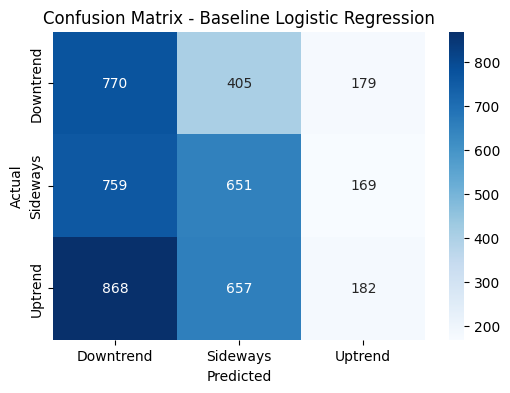

In [23]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Logistic Regression")

plt.savefig('../visuals/model_performance/baseline_logreg_confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()


### Observation of Findings

The confusion matrix reveals that the baseline logistic regression model struggles significantly with multi-class trend prediction. The model heavily over-predicts “Downtrend,” capturing most true Downtrend cases but misclassifying the majority of Sideways and Uptrend observations into this class. Sideways trends are recognized moderately, whereas Uptrend patterns are rarely detected, indicating poor class separation and insufficient feature signal. These results highlight the limitations of a linear model and justify the need for feature engineering and more expressive models in subsequent notebooks.

### To Plot Precision, Recall & F1 by Class

In [25]:
# To generate classification report as a dictionary

report_dict = classification_report(y_test, preds, output_dict=True)
df_report = pd.DataFrame(report_dict).T

# Extract only classes 0, 1, 2

df_scores = df_report.loc[['0', '1', '2'], ['precision', 'recall', 'f1-score']]
df_scores

,precision,recall,f1-score
0,0.321235,0.568685,0.410557
1,0.380035,0.412286,0.395504
2,0.343396,0.106620,0.162718


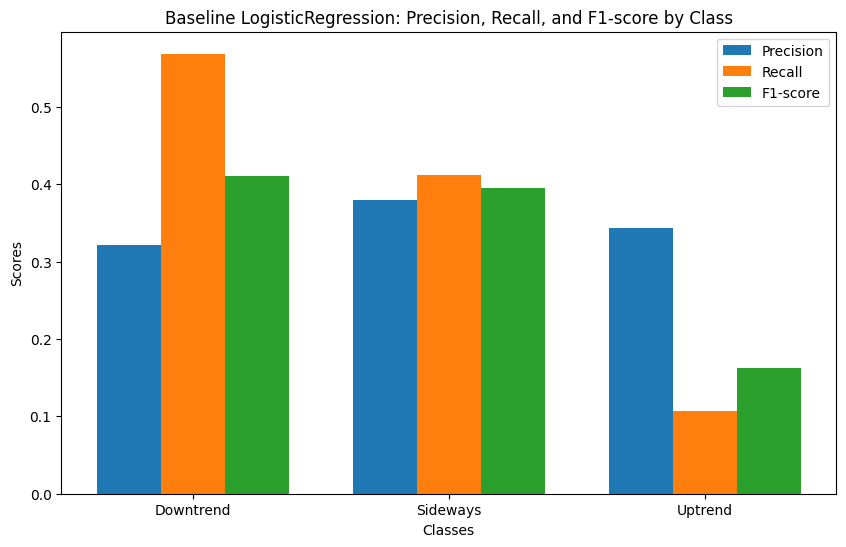

In [27]:
# To plt grouped barchart

# Data
metrics = ['precision', 'recall', 'f1-score']
classes = df_scores.index.tolist()
values = df_scores.values

# Bar positions
x = np.arange(len(classes))   # positions for classes: 0, 1, 2
width = 0.25                  # width of each bar

plt.figure(figsize=(10, 6))

# Plot bars
plt.bar(x - width, values[:, 0], width, label='Precision')
plt.bar(x,         values[:, 1], width, label='Recall')
plt.bar(x + width, values[:, 2], width, label='F1-score')

# Labels and title
class_labels = ['Downtrend', 'Sideways', 'Uptrend']

plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("Baseline LogisticRegression: Precision, Recall, and F1-score by Class")
plt.xticks(x, class_labels)
plt.legend()

plt.savefig('../visuals/model_performance/log_reg_prf1_class.png', dpi=300, bbox_inches='tight')

plt.show()

### Observation of Findings

**Downtrend**

- Recall = 0.57 (highest) - model is good at catching downtrends

- Precision = 0.32, but many of its downtrend predictions are wrong

Meaning: The model tends to over-predict downtrend.

**Sideways**

- Balanced precision/recall (~0.38–0.41)

Meaning: Moderate detectability, but still weak.

**Uptrend**

- Recall = 0.11 (very low)

- F1 = 0.16 - lowest class performance

Meaning: The model almost never detects an actual uptrend correctly.

### Overall Interpretation

The baseline Logistic Regression model provides a realistic starting point for trend prediction, confirming that:

- Market trend direction is difficult to classify using raw or lightly processed technical features.

- The model has a bias toward predicting Downtrend, a sign of overlapping feature distributions.

- Uptrend classification is the weakest, showing the need for stronger momentum/volatility-based engineered features.

This baseline justifies moving to:

- richer feature engineering (Notebook 4)

- adopting more powerful model (Random Forest, tuned RF/XGBoost)

- SHAP/Feature Importance for deeper insights

**In summary:**

- Baseline performance is weak but acceptable as a benchmarking stage.

- It highlights exactly where the model struggles, guiding the next steps in the pipeline.

#### Improvement in accuracy between both models
- -1% - Logistic Regression performed better than random forest.

#### Improvement in F1-Score between both models by class (RF - LR)
- Downtrend (class 0) = 0.30 - 0.27 = +0.03
- Sideways (class 1) = 0.38 - 0.48 = -0.10
- Uptrend (class 2) = 0.36 - 0.21 = +0.15

Random Forest significantly better on a class by class basis, though Logistic Regression is best for sideways.

##### Improvement in overall F1-Score between both models
- Macro F1 = 0.35 - 0.32 = +0.03
- Weighted F1 = 0.35 - 0.32 = +0.03

Random Forest provides more balanced performance across classes with an improvement score of 0.03.

### Prediction Errors

- Sideways periods are easy, but transition into or out of sideways is hard leading to misclassifications
- Downtrend is difficult to predict evident from its low recall score from both models
- Feature and target mismatch. While target is 5-day future return direction, while many features (SMA_50, SMA_200, Volume indicators) capture longer-term behavior causing poor performance during volatile short-term bursts and difficulty detecting near-term reversals or fades.